# Hotel Cancellation — End-to-End Notebook

This notebook combines the three project notebooks: `data-processing.ipynb` -> `eda.ipynb` -> `visualization.ipynb`.

It runs end-to-end from the raw CSV: clean & engineer features, split into train/test early, then run all exploratory analysis and figures.

Anything that becomes a decision (transforms, feature-selections, or outliers) is computed on the training split only. Structural facts with no decision baked in (shape, columns, dtypes, raw missing-value counts, overall target class balance) are shown on the full data. If a val/test row could influence a modeling call, it is treated as leaked.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
print("Done Importing")

Done Importing


## 1. Load Raw Data



In [2]:
df = pd.read_csv("../data/raw/hotel_bookings.csv")
df.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Structural Overview (full data, no split yet)


In [3]:
# Structural facts on the raw data 
print(f"Data shape: {df.shape}")
print("\nColumn names:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nUnique value count per column:\n", df.nunique())
print("\nN/A's per column:\n", df.isna().sum())

Data shape: (119390, 32)

Column names: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

Dtypes:
 hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             i

## 3. Data Cleaning & Feature Engineering


In [4]:
# Handle missing values
df["children"] = df["children"].fillna(0).astype(int)
df["country"] = df["country"].fillna("N/A")

# Keep only bookings with at least one guest
total_guests = df["adults"] + df["children"] + df["babies"]
df = df[total_guests > 0].copy()

# Engineered features
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
df["room_mismatch"] = (df["reserved_room_type"] != df["assigned_room_type"]).astype(int)

# Drop leakage / unused / high-cardinality columns
df = df.drop(columns=["agent", "reserved_room_type", "assigned_room_type", "company",
                      "meal", "market_segment", "reservation_status", "reservation_status_date"])

df["total_guests"] = df["adults"] + df["children"] + df["babies"]
print(f"Data shape after cleaning: {df.shape}")

Data shape after cleaning: (119210, 27)

## 4. Train / Test Split

We split here, before all EDA. From this point on, every decision is made from `train_df` only.


In [5]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["is_canceled"]
)
print(f"Train shape: {train_df.shape}   Test shape: {test_df.shape}")

Train shape: (95368, 27)   Test shape: (23842, 27)


## 5. Outlier Handling (decided on train)

The `adr < 5000` cutoff is chosen from the train distribution and then applied identically to test as a fixed rule. 


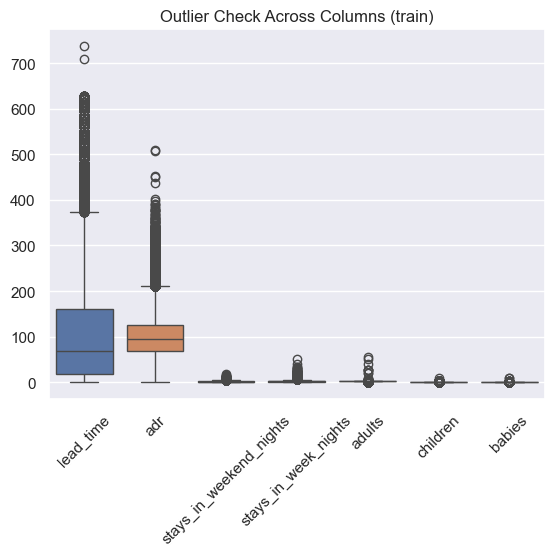

Train shape: (95368, 27)   Test shape: (23841, 27)


In [6]:
numerical_cols = ["lead_time", "adr", "stays_in_weekend_nights", "stays_in_week_nights",
                  "adults", "children", "babies"]
sns.boxplot(train_df[numerical_cols])
plt.title("Outlier Check Across Columns (train)")
plt.xticks(rotation=45)
plt.show()

# One extreme adr outlier exists; apply the same threshold to both splits.
train_df = train_df[train_df["adr"] < 5000].copy()
test_df = test_df[test_df["adr"] < 5000].copy()
print(f"Train shape: {train_df.shape}   Test shape: {test_df.shape}")

## 6. Log Transforms

The skew check that motivates these logs is in the EDA section below (train only). The transform itself is deterministic per row (no fitting), so it is applied to both splits.


In [7]:
for frame in (train_df, test_df):
    frame["lead_time_log"] = np.log1p(frame["lead_time"])
    frame["adr_log"] = np.log1p(frame["adr"])

C:\Users\akimj\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


## 7. Encoding

Any data-driven encoder is fit on train and applied to test. Country frequency encoding uses train frequencies only (unseen test countries map to 0), and test one-hot columns are realigned to the train column set.


In [8]:
one_hot_targets = ["deposit_type", "customer_type", "distribution_channel", "arrival_date_month"]

# hotel to binary
train_df["hotel"] = train_df["hotel"].map({"City Hotel": 1, "Resort Hotel": 0})
test_df["hotel"] = test_df["hotel"].map({"City Hotel": 1, "Resort Hotel": 0})

# Frequency-encode country using TRAIN frequencies only; unseen test countries to 0
country_frequencies = train_df["country"].value_counts(normalize=True)
train_df["country_encoded"] = train_df["country"].map(country_frequencies)
test_df["country_encoded"] = test_df["country"].map(country_frequencies).fillna(0.0)
train_df = train_df.drop(columns=["country"])
test_df = test_df.drop(columns=["country"])

# One-hot encode, then align test columns to the train column set
train_df = pd.get_dummies(train_df, columns=one_hot_targets, drop_first=True, dtype=int)
test_df = pd.get_dummies(test_df, columns=one_hot_targets, drop_first=True, dtype=int)
test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

train_df.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,arrival_date_month_December,arrival_date_month_February,arrival_date_month_January,arrival_date_month_July,arrival_date_month_June,arrival_date_month_March,arrival_date_month_May,arrival_date_month_November,arrival_date_month_October,arrival_date_month_September
32983,0,0,11,2017,6,10,0,2,2,0,...,0,1,0,0,0,0,0,0,0,0
54151,1,1,128,2016,28,7,0,3,2,0,...,0,0,0,1,0,0,0,0,0,0
76714,1,0,7,2016,51,14,0,2,1,0,...,1,0,0,0,0,0,0,0,0,0
2274,0,1,77,2015,41,8,0,3,2,2,...,0,0,0,0,0,0,0,0,1,0
15050,0,0,6,2016,29,13,0,1,1,0,...,0,0,0,1,0,0,0,0,0,0


## 8. Save Processed Data

In [9]:
# full = train + test reassembled in original row order (kept for compatibility)
full_df = pd.concat([train_df, test_df]).sort_index()
full_df.to_csv("../data/processed/processed_data.csv", index=False)
train_df.to_csv("../data/processed/processed_data_train.csv", index=False)
test_df.to_csv("../data/processed/processed_data_test.csv", index=False)
print("Saved processed full / train / test CSVs")

Saved processed full / train / test CSVs


# Exploratory Data Analysis & Visualization

## Goal

Understand the structure, distributions, and predictive signal in the booking data before modeling, pairing each finding with the figure that communicates it.

Everything below runs on `train_df` only: every output feeds a transform, feature-selection, or outlier decision, so it must not see val/test rows. The one exception is the target class-balance figure, a purely structural fact shown on the full data.


In [10]:
# EDA + visualization setup
df = train_df.copy()

# onehot encoding function
def from_onehot(frame, prefix, baseline):
    s = pd.Series(baseline, index=frame.index)
    for c in [c for c in frame.columns if c.startswith(prefix)]:
        s = s.mask(frame[c] == 1, c[len(prefix):])
    return s

# mapping and transforming variables
df["hotel_label"] = df["hotel"].map({1: "City Hotel", 0: "Resort Hotel"})
df["deposit_type"] = from_onehot(df, "deposit_type_", "No Deposit")
df["customer_type"] = from_onehot(df, "customer_type_", "Contract")
df["distribution_channel"] = from_onehot(df, "distribution_channel_", "Corporate")
df["repeated_guest"] = df["is_repeated_guest"].map({0: "No", 1: "Yes"})
df["arrival_month"] = from_onehot(df, "arrival_date_month_", "April")

categorical_cols = ["hotel_label", "deposit_type", "customer_type",
                    "distribution_channel", "repeated_guest"]

overall_rate = df["is_canceled"].mean()
print(f"Train rows: {len(df):,}   Train cancellation rate: {overall_rate:.1%}")

Train rows: 95,368   Train cancellation rate: 37.1%


## 1. Target Variable Balance

Check how (im)balanced the target is. This drives the evaluation choices later (ROC-AUC / PR-AUC over raw accuracy).

Shown on the full data: class balance is a structural fact, not a decision derived from train.

Stayed (0): 62.9 %
Cancelled (1): 37.1 %


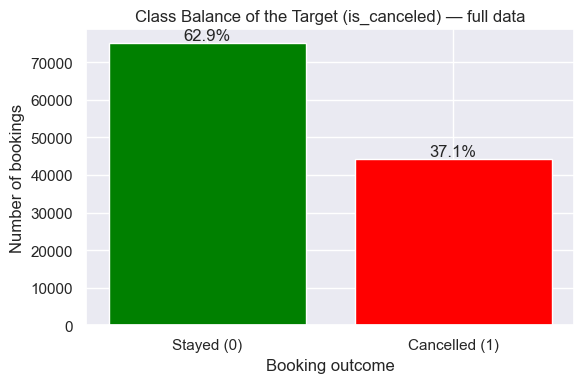

In [11]:
# class balance 
counts = full_df["is_canceled"].value_counts().sort_index()

pct = counts / len(full_df) * 100
print("Stayed (0):", round(pct[0], 1), "%")
print("Cancelled (1):", round(pct[1], 1), "%")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Stayed (0)", "Cancelled (1)"], counts.values, color=["green", "red"])
ax.text(0, counts.values[0], f"{pct[0]:.1f}%", ha="center", va="bottom")
ax.text(1, counts.values[1], f"{pct[1]:.1f}%", ha="center", va="bottom")
ax.set_title("Class Balance of the Target (is_canceled) — full data")
ax.set_xlabel("Booking outcome")
ax.set_ylabel("Number of bookings")
plt.tight_layout()
plt.show()

The figure above shows the split between bookings that were kept and those that were cancelled. Around 37% of the bookings were cancelled, so the classes are somewhat imbalanced but not severely. The cancelled bookings are the ones we actually care about predicting, so accuracy is a misleading metric here: a model that just guesses "not cancelled" every time would already hit about 63%. Because of that I'll focus on ROC-AUC and PR-AUC, which look at how well the model ranks the minority class rather than just how many it gets right overall.

## 2. Distribution Analysis (patterns & skewness)

Examine how the key features are distributed to spot skew, long tails, and dominant categories. This is what motivates the log transforms applied earlier.

In [12]:
num_cols = [
    "lead_time", "adr", "stays_in_week_nights", "stays_in_weekend_nights",
    "previous_cancellations", "booking_changes", "total_of_special_requests", "days_in_waiting_list",
]

print("Numeric feature summary:\n")
print(df[num_cols].describe().round(2).to_string())
print("\nSkewness (high positive = right-skewed):")
print(df[num_cols].skew().round(2).sort_values(ascending=False).to_string())

Numeric feature summary:

       lead_time       adr  stays_in_week_nights  stays_in_weekend_nights  previous_cancellations  booking_changes  total_of_special_requests  days_in_waiting_list
count   95368.00  95368.00              95368.00                 95368.00                95368.00         95368.00                   95368.00              95368.00
mean      104.03    101.85                  2.50                     0.93                    0.09             0.22                       0.57                  2.33
std       106.75     47.94                  1.89                     0.99                    0.83             0.64                       0.79                 17.59
min         0.00      0.00                  0.00                     0.00                    0.00             0.00                       0.00                  0.00
25%        18.00     69.56                  1.00                     0.00                    0.00             0.00                       0.00             

In [13]:
print("Categorical feature counts (sorted by frequency):\n")
for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts().to_string())
    print()

Categorical feature counts (sorted by frequency):

--- hotel_label ---
hotel_label
City Hotel      63433
Resort Hotel    31935

--- deposit_type ---
deposit_type
No Deposit    83567
Non Refund    11669
Refundable      132

--- customer_type ---
customer_type
Transient          71625
Transient-Party    20059
Contract            3236
Group                448

--- distribution_channel ---
distribution_channel
TA/TO        78260
Direct       11684
Corporate     5265
GDS            155
Undefined        4

--- repeated_guest ---
repeated_guest
No     92347
Yes     3021



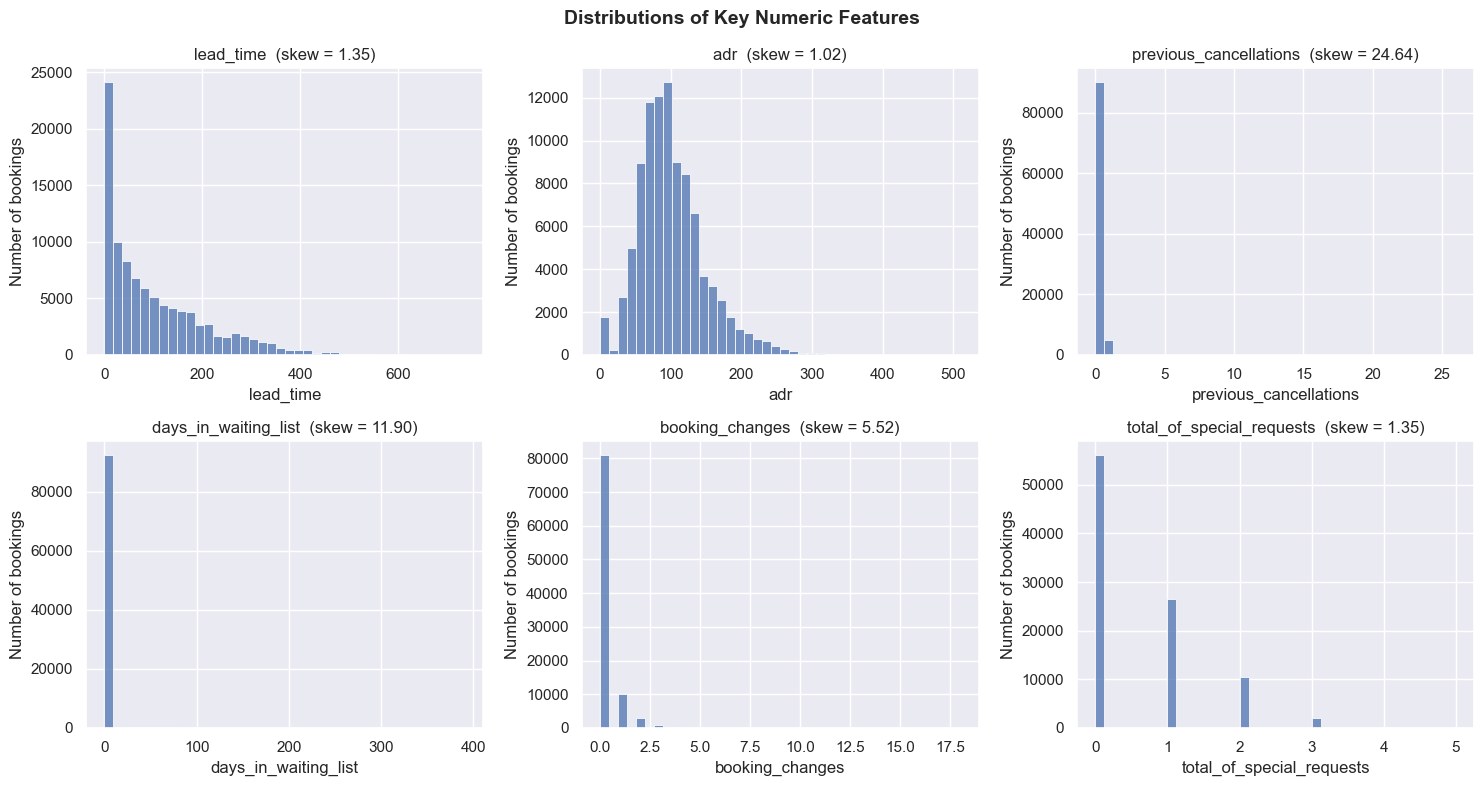

In [14]:
# histograms of the key numeric features
dist_cols = ["lead_time", "adr", "previous_cancellations",
             "days_in_waiting_list", "booking_changes", "total_of_special_requests"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), dist_cols):
    sns.histplot(df[col], bins=40,  ax=ax)
    ax.set_title(f"{col}  (skew = {df[col].skew():.2f})")
    ax.set_xlabel(col)
    ax.set_ylabel("Number of bookings")

fig.suptitle("Distributions of Key Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

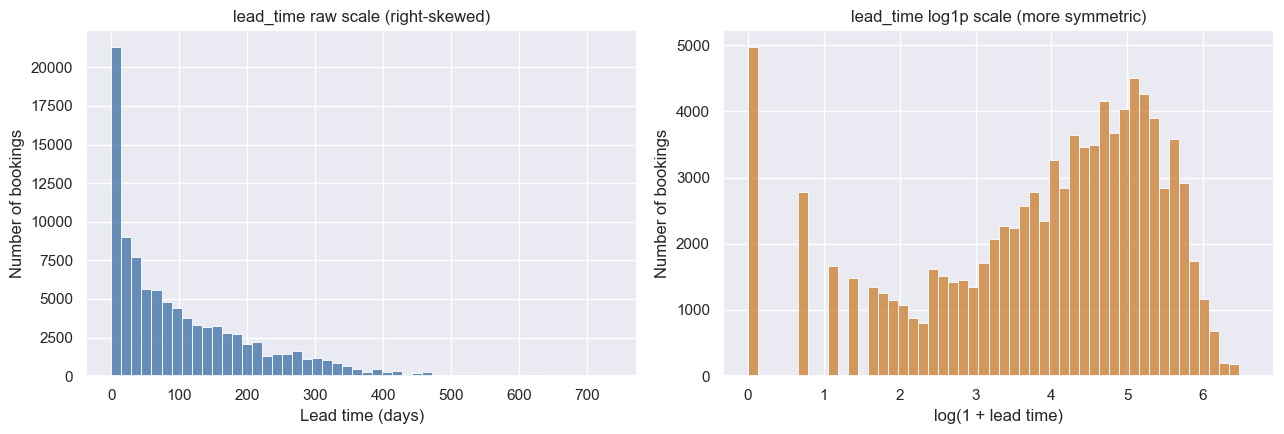

In [15]:
# lead_time is strongly right-skewed. Compare raw vs log scale
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["lead_time"], bins=50, color="#3A6EA5", ax=axes[0])
axes[0].set_title("lead_time raw scale (right-skewed)")
axes[0].set_xlabel("Lead time (days)")
axes[0].set_ylabel("Number of bookings")

sns.histplot(df["lead_time_log"], bins=50, color="#C97B2B", ax=axes[1])
axes[1].set_title("lead_time log1p scale (more symmetric)")
axes[1].set_xlabel("log(1 + lead time)")
axes[1].set_ylabel("Number of bookings")

plt.tight_layout()
plt.show()

The summary and figures above show each key numeric feature's distribution, plus a raw-vs-log comparison for lead_time. The numeric features are mostly right-skewed. `previous_cancellations`, `days_in_waiting_list`, and `booking_changes` are zero for almost every booking with a few rare large values, while lead_time and adr are continuous but have long right tails which is why lead_time and adr get the log1p transforms.

## 3. Feature vs. Target Relationships

How each feature relates to `is_canceled`: per-category cancellation rates against the overall baseline, and the lead-time signal.

In [16]:
print(f"Cancellation rate by category (overall = {overall_rate:.1%})\n")
for col in categorical_cols:
    print(f"--- {col} ---")
    print(df.groupby(col)["is_canceled"].mean().sort_values(ascending=False).round(3).to_string())
    print()

Cancellation rate by category (overall = 37.1%)

--- hotel_label ---
hotel_label
City Hotel      0.416
Resort Hotel    0.280

--- deposit_type ---
deposit_type
Non Refund    0.993
No Deposit    0.284
Refundable    0.212

--- customer_type ---
customer_type
Transient          0.408
Contract           0.312
Transient-Party    0.254
Group              0.098

--- distribution_channel ---
distribution_channel
Undefined    0.750
TA/TO        0.410
Corporate    0.223
GDS          0.194
Direct       0.177

--- repeated_guest ---
repeated_guest
No     0.378
Yes    0.147



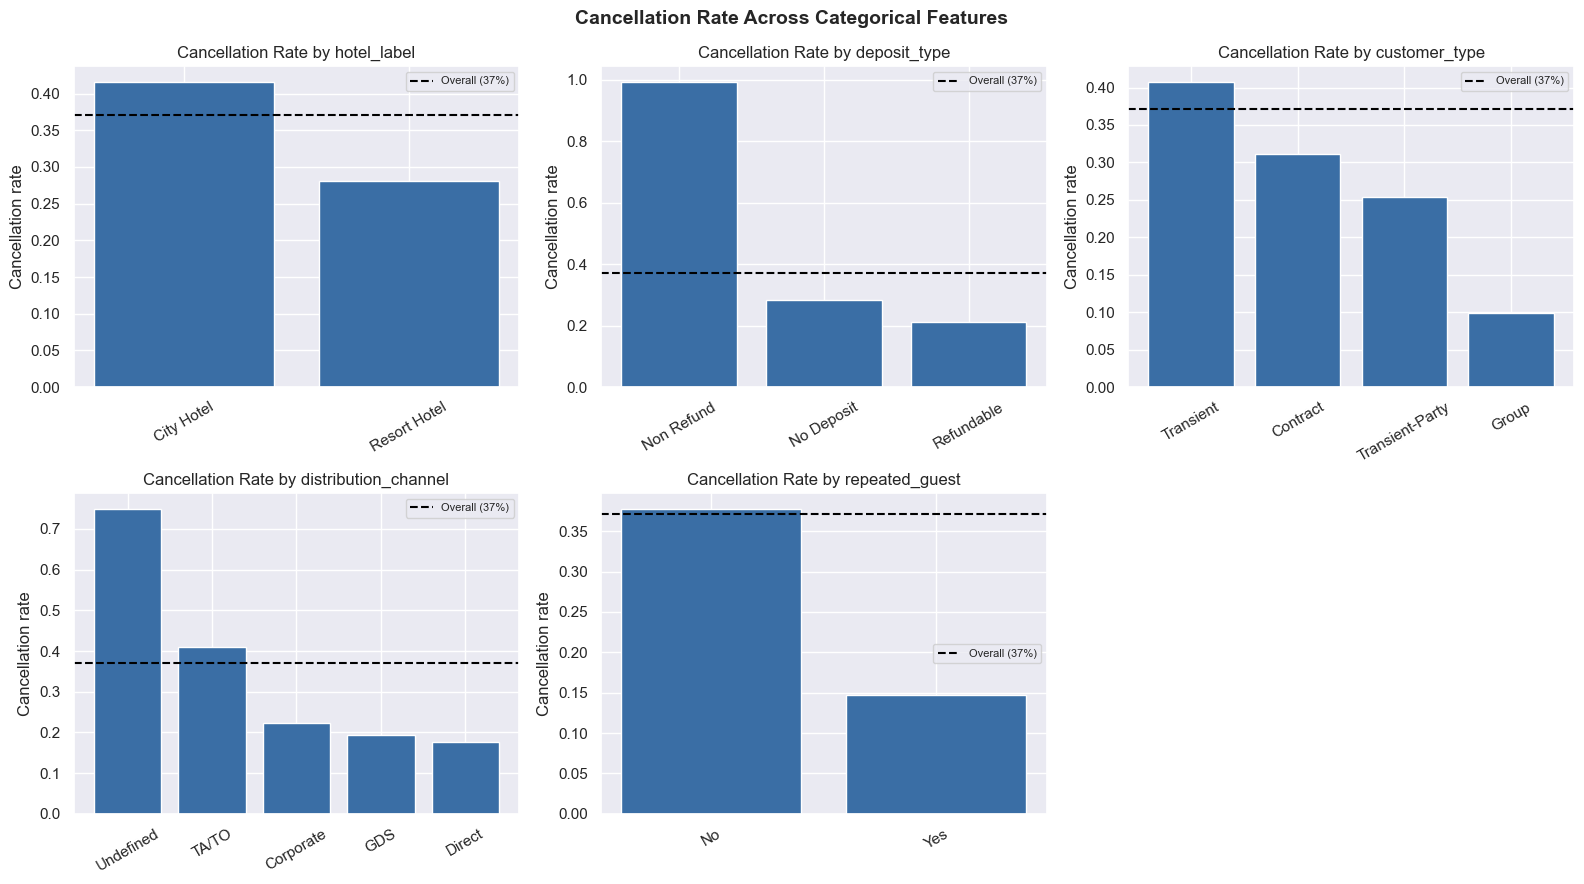

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, col in zip(axes, categorical_cols):
    rate = df.groupby(col)["is_canceled"].mean().sort_values(ascending=False)
    ax.bar(rate.index.astype(str), rate.values, color="#3A6EA5")
    ax.axhline(overall_rate, color="black", linestyle="--",
               label=f"Overall ({overall_rate:.0%})")
    ax.set_title(f"Cancellation Rate by {col}")
    ax.set_ylabel("Cancellation rate")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)

axes[-1].axis("off")  # hide the unused 6th panel
fig.suptitle("Cancellation Rate Across Categorical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

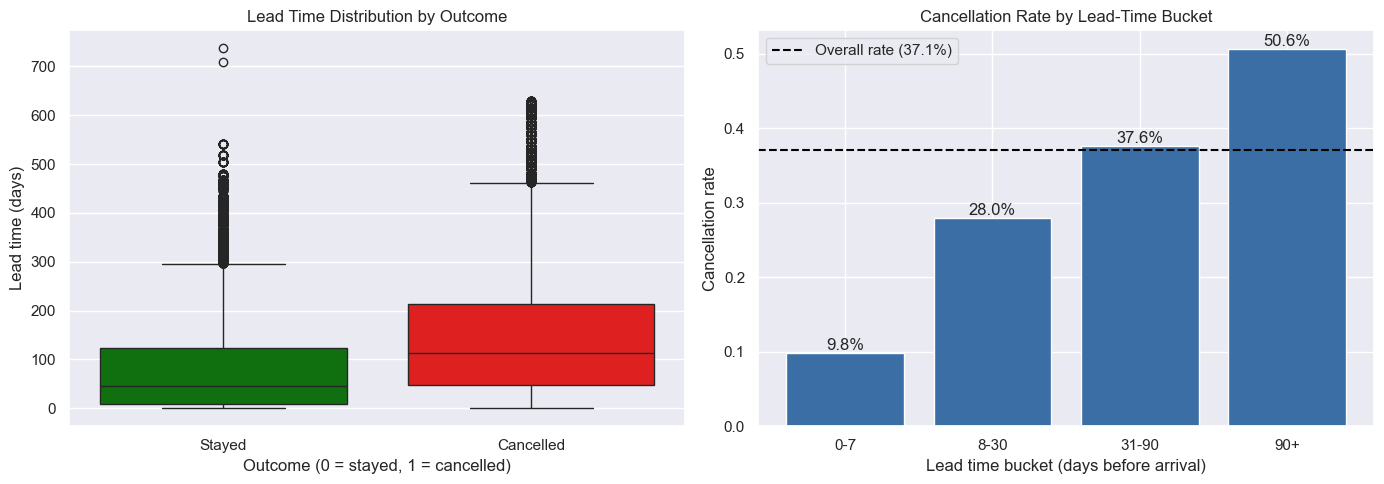

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="is_canceled", y="lead_time",
            hue="is_canceled", palette={0: "green", 1: "red"}, legend=False, ax=axes[0])
axes[0].set_title("Lead Time Distribution by Outcome")
axes[0].set_xlabel("Outcome (0 = stayed, 1 = cancelled)")
axes[0].set_ylabel("Lead time (days)")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Stayed", "Cancelled"])

bins = [-1, 7, 30, 90, np.inf]
labels = ["0-7", "8-30", "31-90", "90+"]
bucket_rate = df.groupby(pd.cut(df["lead_time"], bins=bins, labels=labels),
                         observed=True)["is_canceled"].mean()
bars = axes[1].bar(bucket_rate.index.astype(str), bucket_rate.values, color="#3A6EA5")
for b, v in zip(bars, bucket_rate.values):
    axes[1].text(b.get_x() + b.get_width() / 2, v, f"{v:.1%}", ha="center", va="bottom")
axes[1].axhline(overall_rate, color="black", linestyle="--",
                label=f"Overall rate ({overall_rate:.1%})")
axes[1].set_title("Cancellation Rate by Lead-Time Bucket")
axes[1].set_xlabel("Lead time bucket (days before arrival)")
axes[1].set_ylabel("Cancellation rate")
axes[1].legend()

plt.tight_layout()
plt.show()

Lead time is the strongest numeric predictor: cancelled bookings have a higher median lead time, and risk increases monotonically from ~10% for last-minute bookings (0–7 days) to over 50% for bookings made 90+ days out. This is a reliable early risk signal available the moment a booking is made.

Across the categorical features, the most surprising result is that non-refundable deposits cancel about 99% of the time. This is analyzed deeper in section 7.

Furthermore, City Hotels cancel more than Resort Hotels, Transient customers more than Groups, TA/TO channel more than Direct, and repeat guests cancel far less than first-timers. The `distribution_channel` panel also shows a tiny `Undefined` level cancelling very high, but it covers only a handful of bookings with a missing channel, so I treat it as a low-volume data-quality artifact rather than a trustworthy signal.

## 4. Correlation Analysis

How numeric features relate to the target and to each other. The heatmap is annotated with the exact Pearson values, the ranked bar chart shows the top features by absolute correlation with the target, and the scatter contrasts the two main continuous features.

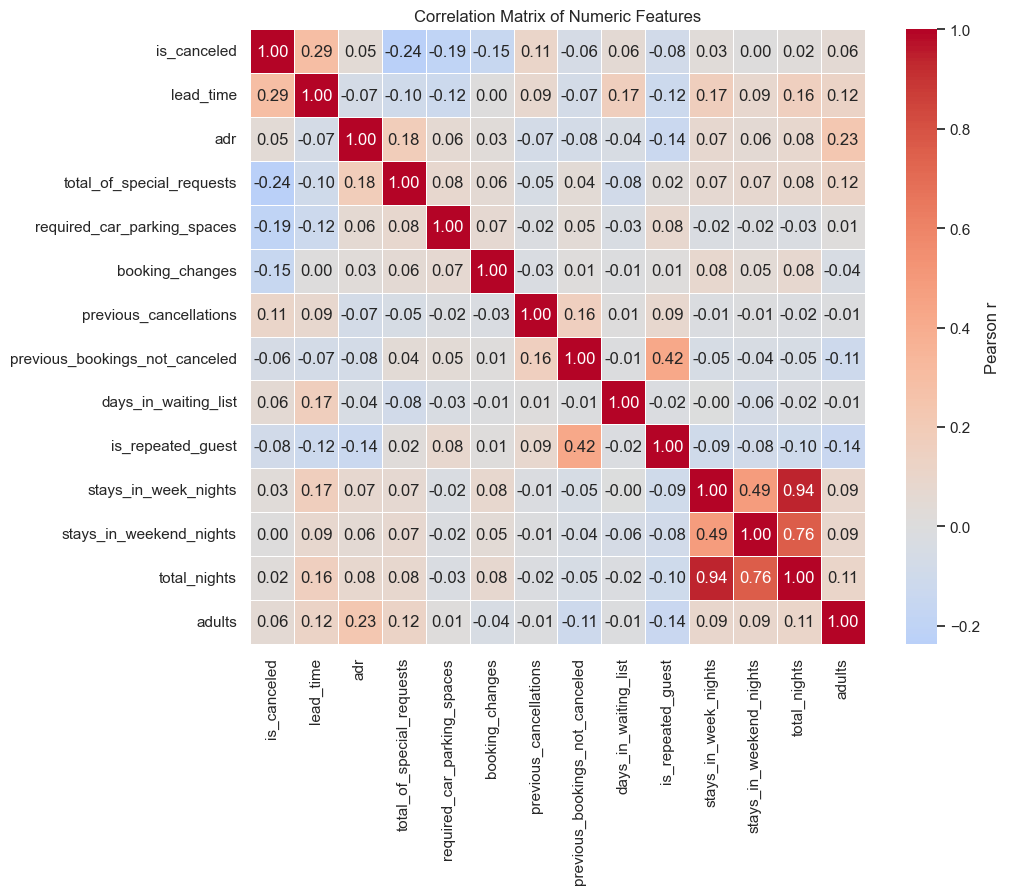

In [19]:
heat_cols = [
    "is_canceled", "lead_time", "adr", "total_of_special_requests",
    "required_car_parking_spaces", "booking_changes", "previous_cancellations",
    "previous_bookings_not_canceled", "days_in_waiting_list", "is_repeated_guest",
    "stays_in_week_nights", "stays_in_weekend_nights", "total_nights", "adults",
]
corr = df[heat_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

Top 15 features by |correlation| with is_canceled:

deposit_type_Non Refund           0.481
country_encoded                   0.325
lead_time                         0.293
room_mismatch                    -0.247
total_of_special_requests        -0.236
required_car_parking_spaces      -0.195
distribution_channel_TA/TO        0.174
distribution_channel_Direct      -0.150
booking_changes                  -0.146
customer_type_Transient           0.133
hotel                             0.133
customer_type_Transient-Party    -0.125
previous_cancellations            0.110
is_repeated_guest                -0.084
previous_bookings_not_canceled   -0.057


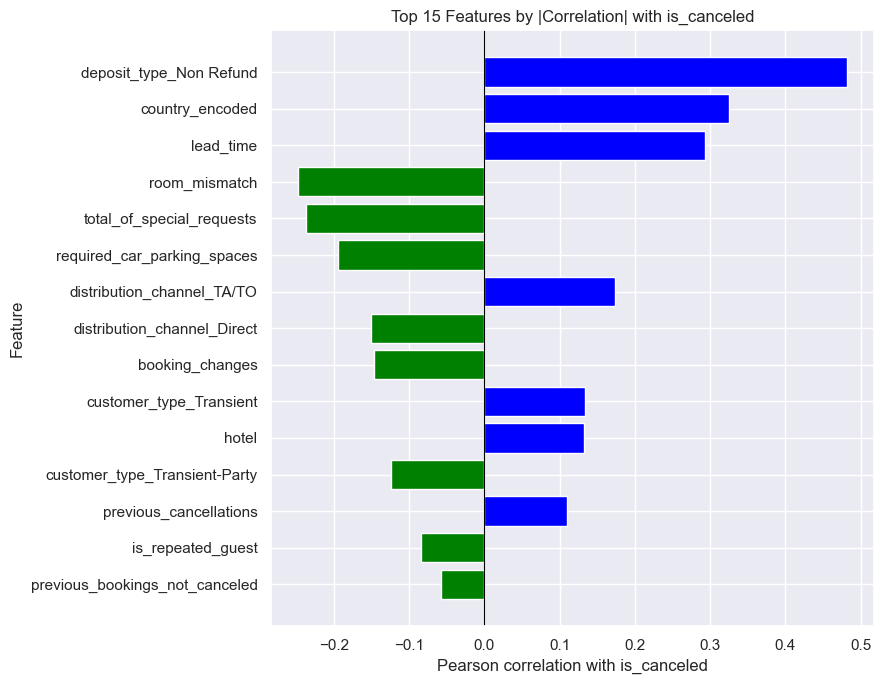

In [20]:
target_corr = (
    df.select_dtypes("number")
      .drop(columns=["is_canceled", "lead_time_log", "adr_log"])
      .corrwith(df["is_canceled"])
)
top = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).head(15)

print("Top 15 features by |correlation| with is_canceled:\n")
print(top.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["blue" if v > 0 else "green" for v in top.values]
ax.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 15 Features by |Correlation| with is_canceled")
ax.set_xlabel("Pearson correlation with is_canceled")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

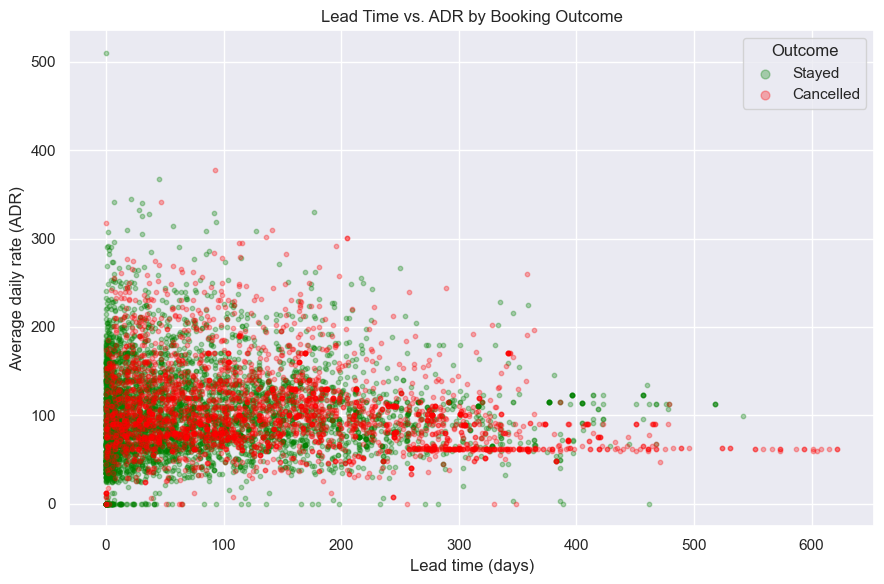

In [21]:
# scatter of the two main continuous features, colored by outcome (sampled to keep the plot readable)
sample = df.sample(n=8000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
for outcome, color, lbl in [(0, "green", "Stayed"), (1, "red", "Cancelled")]:
    sub = sample[sample["is_canceled"] == outcome]
    ax.scatter(sub["lead_time"], sub["adr"], s=10, alpha=0.3,
               color=color, label=lbl)
ax.set_title("Lead Time vs. ADR by Booking Outcome")
ax.set_xlabel("Lead time (days)")
ax.set_ylabel("Average daily rate (ADR)")
ax.legend(title="Outcome", markerscale=2)
plt.tight_layout()
plt.show()

No single numeric feature is collinear enough to be redundant except by construction (`total_nights` = week + weekend nights). Against the target, `deposit_type_Non Refund` (+0.48), `country_encoded` (+0.32) and `lead_time` (+0.29) push risk up. Engagement signals `total_of_special_requests`, `required_car_parking_spaces`, `room_mismatch`, and `booking_changes` pull it down. The red/green split shows risk-raising vs. risk-lowering features at a glance.

The scatter reinforces this: cancelled bookings (red) spread noticeably further to the right along the lead-time axis, while stayed bookings (green) cluster at short lead times. ADR shows no clean vertical separation,  cancellations occur across the full price range, matching its near-zero linear correlation.

## 5. Time-Based Patterns

Cancellation rate and booking volume by arrival month, in calendar order (`arrival_month` reconstructed from the one-hot columns, April being the dropped baseline).

Cancellation rate by arrival month (overall = 37.1%):

arrival_month
January      0.306
February     0.337
March        0.324
April        0.408
May          0.395
June         0.416
July         0.375
August       0.378
September    0.386
October      0.381
November     0.314
December     0.350


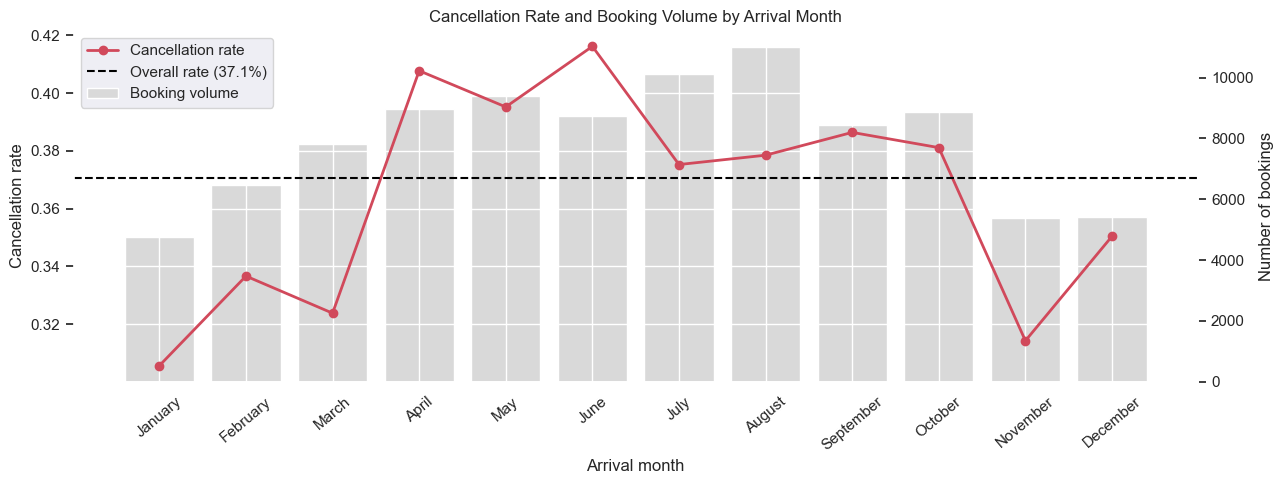

In [22]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
month_rate = df.groupby("arrival_month")["is_canceled"].mean().reindex(month_order)
month_vol = df["arrival_month"].value_counts().reindex(month_order)

print(f"Cancellation rate by arrival month (overall = {overall_rate:.1%}):\n")
print(month_rate.round(3).to_string())

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax2.bar(month_order, month_vol.values, color="#D9D9D9", label="Booking volume")
ax1.plot(month_order, month_rate.values, color="#D1495B", marker="o",
         linewidth=2, label="Cancellation rate")
ax1.axhline(overall_rate, color="black", linestyle="--",
            label=f"Overall rate ({overall_rate:.1%})")

ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)
ax1.set_title("Cancellation Rate and Booking Volume by Arrival Month")
ax1.set_xlabel("Arrival month")
ax1.set_ylabel("Cancellation rate")
ax2.set_ylabel("Number of bookings")
ax1.tick_params(axis="x", rotation=40)

lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbl1 + lbl2, loc="upper left")
plt.tight_layout()
plt.show()

Cancellation rate peaks in spring/early summer (April–June, ~40%) and dips in winter (January, November, ~31%). Booking volume is highest in the busy summer months, so absolute cancellations concentrate there even when the rate is similar. There is a usable seasonal component, though it is weaker than the deposit/lead-time signals.

## 6. Feature Importance (Mutual Information)

Mutual information captures non-linear dependence between each feature and the target, complementing the linear correlation view above.

Feature importance by mutual information (top 15):

deposit_type_Non Refund        0.1324
lead_time                      0.0810
adr                            0.0774
country_encoded                0.0724
previous_cancellations         0.0433
total_of_special_requests      0.0405
room_mismatch                  0.0402
required_car_parking_spaces    0.0286
distribution_channel_TA/TO     0.0246
booking_changes                0.0203
hotel                          0.0195
customer_type_Transient        0.0175
total_nights                   0.0147
days_in_waiting_list           0.0133
distribution_channel_Direct    0.0108


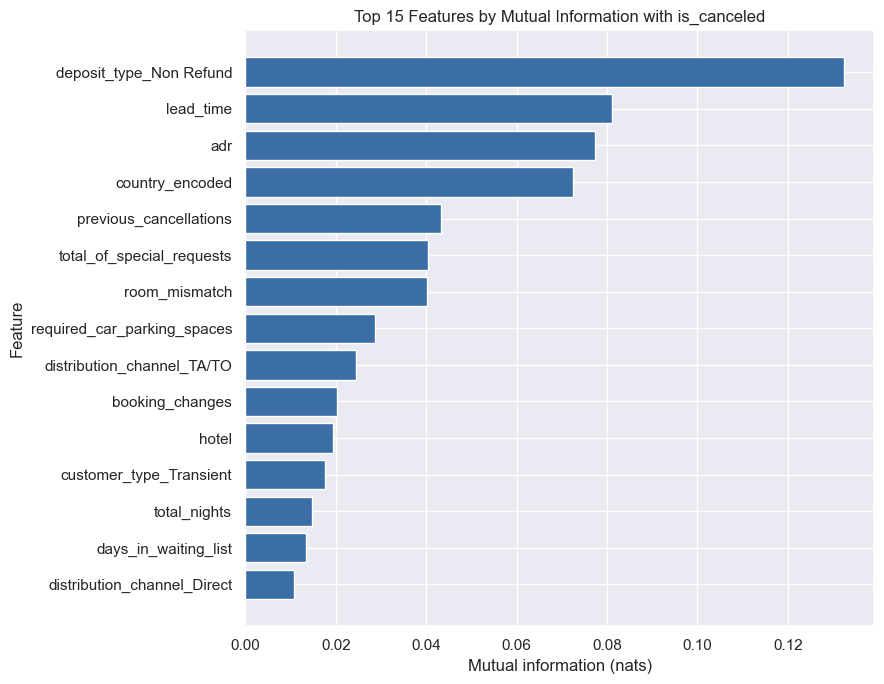

In [23]:
feature_cols = [c for c in df.select_dtypes("number").columns
                if c not in ("is_canceled", "lead_time_log", "adr_log")]
X = df[feature_cols].fillna(0)
y = df["is_canceled"]

mi_scores = mutual_info_classif(X, y, random_state=42)
mi = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

print("Feature importance by mutual information (top 15):\n")
print(mi.head(15).round(4).to_string())

mi_top = mi.head(15)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(mi_top.index[::-1], mi_top.values[::-1], color="#3A6EA5")
ax.set_title("Top 15 Features by Mutual Information with is_canceled")
ax.set_xlabel("Mutual information (nats)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

Mutual information agrees with the correlation ranking on the leaders (`deposit_type_Non Refund`, `lead_time`, `adr`, and `country_encoded`) carry the most signal. However, it surfaces `adr` more strongly, hinting at a non-linear price effect that linear correlation understates. These features are the priority inputs for the baseline and boosted models.

## 7. Deposit-Type Deep Dive (leakage check)

`deposit_type_Non Refund` looks suspicious — it cancels ~99% of the time.

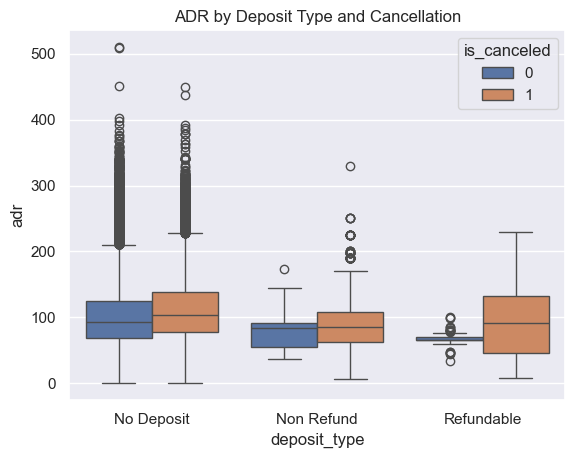

In [24]:
df.groupby(['deposit_type', 'is_canceled'])['adr'].describe()
sns.boxplot(data=df, x='deposit_type', y='adr', hue='is_canceled')
plt.title('ADR by Deposit Type and Cancellation')
plt.show()

In [25]:
# How many samples are in each group?
df.groupby(['deposit_type', 'is_canceled']).size().unstack()

is_canceled,0,1
deposit_type,,
No Deposit,59827,23740
Non Refund,78,11591
Refundable,104,28


In [26]:
df[df['deposit_type'] == 'Non Refund']['distribution_channel'].value_counts(normalize=True)

distribution_channel
TA/TO        0.936413
Corporate    0.036336
Direct       0.027252
Name: proportion, dtype: float64

For the "non refund" deposit type, 93% of cancellations from TA/TO (Travel Agency and Travel Operator like booking.com). The assumption here is that TA/TO's own cancellation policy was reflected.

## 8. Summary

Baseline cancellation rate: **~37%** (train) is a moderate class imbalance, so models are evaluated with **ROC-AUC / PR-AUC** rather than raw accuracy.

**Strongest risk drivers**
- `deposit_type_Non Refund`: ~99% cancel rate, the single strongest signal (r ≈ 0.48) with a leakage risk (see the deposit deep-dive) so this will be treated with caution.
- `lead_time`: cancel rate climbs from ~10% (0–7 days) to ~51% (90+ days); median lead time ~45 days for stayed vs. ~113 for cancelled.
- `country_encoded`: second-strongest positive predictor (r ≈ 0.32); consider country-level risk tiers.
- `distribution_channel_TA/TO`: travel agent/operator bookings cancel more than Direct.

**Strongest protective signals**
- Engagement lowers risk: `total_of_special_requests` (r ≈ −0.24), `required_car_parking_spaces` (r ≈ −0.20), `booking_changes` (r ≈ −0.15).
- Repeat guests cancel ~15% vs. ~38% for first-timers.

**Other patterns**
- Seasonality: spring/early-summer arrivals cancel most (June ~42%, April ~41%); winter least (January ~30%, November ~31%).
- Skew: most numeric features are right-skewed, which is why `lead_time` and `adr` get log transforms.
- Redundant by construction: `total_nights` = week + weekend nights; `lead_time_log` / `adr_log` duplicate their raw counterparts.
